<font color='red' size='6'>REMINDER</font>

# Fill in any place that says `YOUR CODE HERE`.
- You should remove the line that says `raise NotImplementedError()`. If you do not, your code will (unsurprisingly) throw a run-time error and cause everything to fail.
- Do **NOT** write your answer anywhere else other than where it says `YOUR CODE HERE`. Simply write your code directly below this comment in the **same code cell**.

# Make sure everything runs as expected.
- Go to the menubar, select *Kernel* > *Restart & Run All*

# Do <ins>NOT</ins> change the title (i.e., file name) of this notebook.

# Do <ins>NOT</ins> delete any of the cells in this notebook.

# Make sure you save your work
- Go to the menubar, select *File* > *Save and Checkpoint*

In [ ]:
# Run this code cell
from nose.tools import assert_equal, assert_in, assert_is_instance
from nose.tools import assert_almost_equal, assert_not_equal, assert_not_in

# 1. Getting Data

Pallet Movers has given you some data in a Microsoft Excel file named `pm_data.xlsx`. It is found in the folder named `data`. You want to explore this data. Using `pandas`, read the entire spreadsheet into a variable named `pm_data`. How many worksheets are there? Store your answer in a variable named `num_sheets`.

In [ ]:
import pandas as pd
pm_data = pd.read_excel('./data/pm_data.xlsx', sheet_name=None)
num_sheets = len(pm_data)

In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(type(pm_data), dict, msg='Your pm_data variable is not a dictionary')

<hr>

<hr>

# 2. Pull Out Requests

Create a new `DataFrame` variable named `requests` that contains a **deep copy** of the requests from the original data set.

In [ ]:
requests = pm_data['requests'].copy(deep=True)
requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294 entries, 0 to 1293
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   request_id                    1294 non-null   object
 1   origin_city                   1294 non-null   object
 2   origin_state                  1294 non-null   object
 3   origin_liftgate_service       1294 non-null   int64 
 4   destination_city              1294 non-null   object
 5   destination_state             1294 non-null   object
 6   destination_liftgate_service  1294 non-null   int64 
 7   handling_unit                 1294 non-null   object
 8   length                        1294 non-null   int64 
 9   width                         1294 non-null   int64 
 10  height                        1294 non-null   int64 
 11  weight                        1294 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 121.4+ KB


# 3. Weight Distribution

One of the variables for requests that you are interested in exploring is the distribution of the weight. Use `seaborn` to create a histogram of the weight associated with all the requests. Use your `requests` variable that you created earlier and use the default settings when creating the histogram with `seaborn`.

<Figure size 640x480 with 0 Axes>

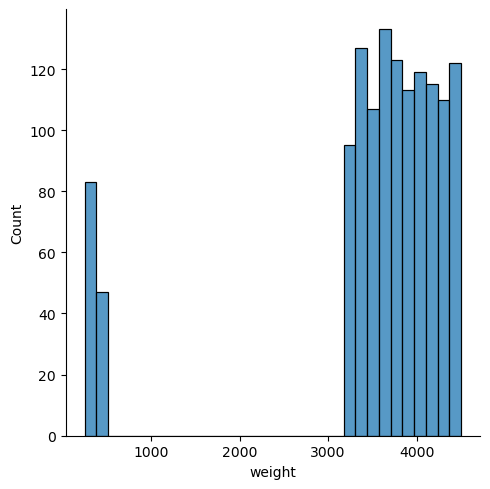

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.displot(data=requests, x='weight', kind='hist')

## Carefully explain the histogram for `weight` in the markdown cell below.

We observe a significant gap between shipments less than 1000 lbs and shipments above 3000 lbs. We do not observe any shipments between 1000 and 3000 lbs. Data is likely left-skewed due to the presence of shipments under 1000 lbs.

# 4. Weight Distribution by Type

Use `seaborn` to create  a box plot of the weight broken out by handling unit. Use your `requests` variable that you created earlier.

<AxesSubplot:xlabel='handling_unit', ylabel='weight'>

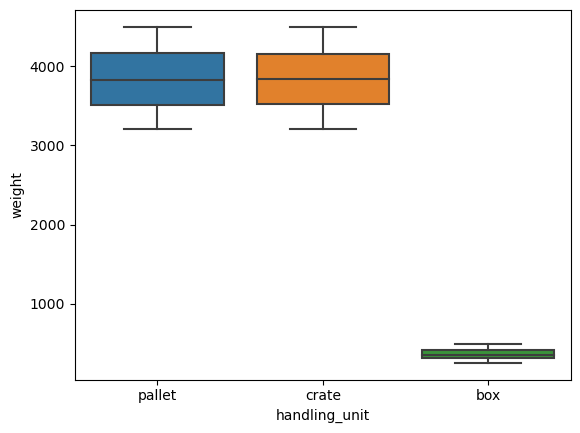

In [ ]:
sns.boxplot(data=requests, x='handling_unit', y='weight')

## Carefully explain the box plot you created in the markdown cell below.

Boxes weigh less than crates and pallets. Crates and pallets have similar averages and ranges of weight. Data is skewed left due to boxes.

# 5. Weight by Origin State

Create a horizontal bar chart with the following attributes:

- The $y$-axis contains each origin state.
- The length of the bar for each origin state is the **sum** of the weight for all requests for that particular origin state.
- The state with the largest amount of weight should be top, with the second-largest second, etc.
- Each bar should have a label to the far right with sum of the weight formatted to thousands of pounds. For example, if the total weight for the state of Virginia was 54,670 pounds, then the label should be "54.67K".
- Format the $x$-tick marks similarly, e.g., ###.##K.
- Include a title for the chart as "Total Weight Across All Origin States: ##.##M Pounds".

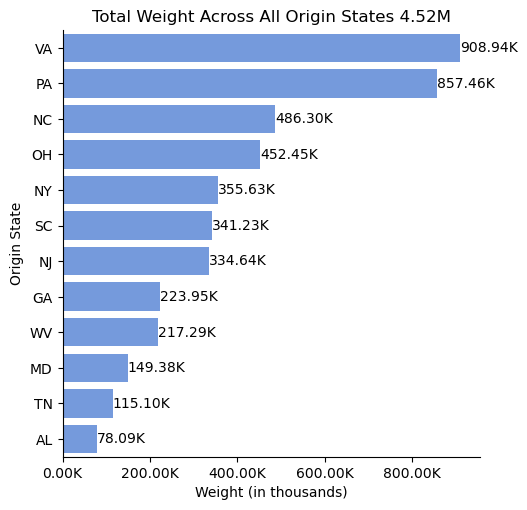

In [ ]:
from matplotlib.ticker import FuncFormatter
g = sns.catplot(data=requests,
            x='weight',
            y='origin_state',
            kind='bar',
            estimator=sum,
            palette=['cornflowerblue'],
            errorbar=None,
            order=requests.groupby('origin_state')['weight'].sum().sort_values(ascending=False).index)

ax = g.facet_axis(0, 0)
ax.set(xlabel='Weight (in thousands)',
       ylabel='Origin State',
       title=f'Total Weight Across All Origin States {requests.weight.sum()/1000000:.2f}M')

for c in ax.containers:
    labels = [f'{(v.get_width())/1000:.2f}K' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge')

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: '{:,.2f}'.format(x/1000) + 'K'))

# 6. Weight by Destination State

Create a horizontal bar chart with the following attributes:

- The $y$-axis contains each destination state.
- The length of the bar for each destination state is the **sum** of the weight for all requests for that particular destination state.
- The state with the largest amount of weight should be top, with the second-largest second, etc.
- Each bar should have a label to the far right with sum of the weight formatted to thousands of pounds. For example, if the total weight for the state of Virginia was 54,670 pounds, then the label should be "54.67K".
- Format the $x$-tick marks similarly, e.g., ###.##K.
- Include a title for the chart as "Total Weight Across All Destination States: ##.##M Pounds".

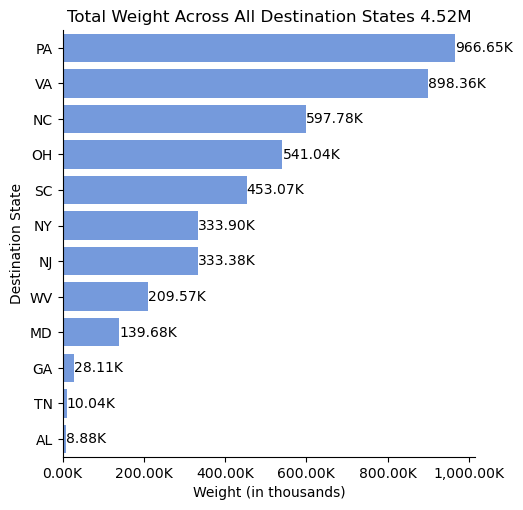

In [ ]:
from matplotlib.ticker import FuncFormatter
d = sns.catplot(data=requests,
            x='weight',
            y='destination_state',
            kind='bar',
            estimator=sum,
            palette=['cornflowerblue'],
            errorbar=None,
            order=requests.groupby('destination_state')['weight'].sum().sort_values(ascending=False).index)

ax = d.facet_axis(0, 0)
ax.set(xlabel='Weight (in thousands)',
       ylabel='Destination State',
       title=f'Total Weight Across All Destination States {requests.weight.sum()/1000000:.2f}M')

for c in ax.containers:
    labels = [f'{(v.get_width())/1000:.2f}K' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge')

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: '{:,.2f}'.format(x/1000) + 'K'))

## Based on the two bar charts you created, what insights can you provide to Pallet Movers? Answer in the markdown cell below.

VA, PA, and NC were the top three for total weight across all origin and destination states. AL and TN were the lowest for total weight across all origin and destination states.

# 7. Cube Size and Weight

Add a new column named `cubic_inches` to your variable `requests`. Cubic inches is the length multiplied by the width multiplied by the height.  

In [ ]:
requests['cubic_inches'] = requests['length'] * requests['width'] * requests['height']

In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_in('cubic_inches', requests.columns, msg='You did not add the column cubic_inches to requests')

In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_not_in('cubic_inches', pm_data['requests'].columns, msg='You did not correctly copy the original data. You have modified the original data.')

# 8. Correlation

Find the correlation coefficent between `cubic_inches` and `weight`. Store your results in a variable named `corr_cube_weight`.

In [ ]:
corr_cube_weight = requests['cubic_inches'].corr(requests['weight'])
corr_cube_weight

0.6432302131578226

In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_in('corr_cube_weight', dir(), msg='You did not correctly name your variable `corr_cube_weight`')

<hr>

# 9. Scatter Plot

Think carefully about the most appropriate direction of possible influence between the variables `weight` and `cubic_inches`.
1. Create a variable named `sample` that stores the result of taking a sample of 150 rows from `requests` using a random seed of 91.
2. Using the variable `sample`, create a scatter plot between the `weight` and `cubic_inches`. Color the markers based on the handling unit and make them all **open circles**. Be sure you have correctly placed the variables on the appropriate axes.

In [ ]:
sample = requests.sample(n=150, random_state=91)

In [ ]:
# This is a test cell
# If **NO** message is printed, it means that the tests passed
# One basic test to see if your code works
assert_equal(len(sample), 150, msg='You did not take a sample of 150 rows')

<Figure size 640x480 with 0 Axes>

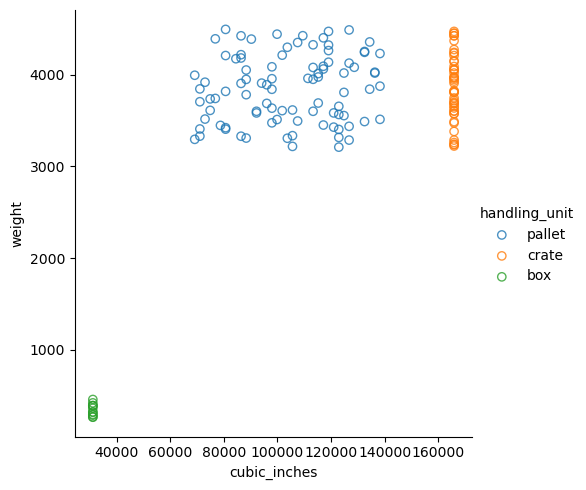

In [ ]:
plt.figure()
sns.lmplot(x='cubic_inches', y='weight', data=sample, hue='handling_unit', fit_reg=False,
          scatter_kws={'facecolor':'none'})

## What insights can you draw from your scatter plot? Answer in the  markdown cell below.

Boxes have the same dimensions, regardless of weight. Boxes weight varies roughly between 250 to 500 lbs. Crates have the same dimensions, regardless of weight. Crates weight varies roughly between 3200 and 4500 lbs. Pallet dimensions roughly varies between 69000 and 139000 cubic inches. Pallet weight varies between 3200 and 4500 lbs, similar to crates. We do not observe a significant correlation between size and weight.

**&copy; 2022 - Present: Matthew D. Dean, Ph.D.   
Clinical Associate Professor of Business Analytics at William \& Mary.**